In [71]:
# Statistical tests using the data 

# load the correponding dataset 
# Study of interactions
# Study of mediation/moderation
# Testing different models with variants on covariates, mean-centering, random effects etc

In [72]:
import numpy as np
import pandas as pd

from scipy.stats import shapiro   # for normality test

from scipy.stats import f_oneway  # for Anova test (normal distribution)
from scipy.stats import kruskal   # for Kruskal-Wallis test (non-normal distribution)

import statsmodels.api as sm      # for Ancova, , non-formular form
import statsmodels.formula.api as smf # for ANCOVA test, formular form

from scipy.stats import rankdata  # for Rank-Based ANCOVA, for Non-Gaussian distributions

import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
curRoot = 'C'  # 'C' or 'D'

In [74]:
# Load shape measures, SELECTED
curRegion = 'CSSyl' # !!! modify !!! CSSyl, CSpreCS
curSCA = 1         # !!! modify !!!
typeDist = 'max'

##############################################   Original   #############################################
# for CSpreCS analysis
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca1_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca2_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca3_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca7_time1_{typeDist}.csv'

#file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'

# Time 1 and 2 separated, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_{typeDist}.csv'

# Time 1 and 2 combined, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_{typeDist}.csv'

#Original, time1 only
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_{typeDist}.csv'

#Original REDO for verification
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\ORI\ORI_time1_ctl_sca1\{curRegion}\combined_time1_{typeDist}_ctl_sca1.csv'

# SCAs 2, 3, 7
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_{typeDist}.csv'

###########################################    RELABEL     #############################################
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'

###########################################   RELABEL, REDO    #############################################
curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_{typeDist}_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time2_ctl_sca{curSCA}\{curRegion}\combined_time2_{typeDist}_ctl_sca{curSCA}.csv'


print(curPath)
combined = pd.read_csv(curPath)
print(len(combined))

### !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!  ###
####################################  only for time1 and 2 together  ####################################
#combined_time1 = combined[combined['Time_point']==1]
#combined_time2 = combined[combined['Time_point']!=1] # BIOSCA==2, CERMOI==3
#combined = combined_time2         ###########################    CHANGE    #############################
### !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!  ###

combined.index = combined['subjName']

# for specific analysis, remove NAs
combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_only_SCA = combined[combined['SCA'] == curSCA]
combined_only_ctl = combined[combined['SCA'] == 0]

combined_only_ctl_BIOSCA = combined[(combined['SCA'] == 0) & (combined['CodeICM'] == 'BIOSCA')]
combined_only_ctl_CERMOI = combined[(combined['SCA'] == 0) & (combined['CodeICM'] == 'CERMOI')]

combined_CAG = combined.dropna(subset=['CAG'])
combined_CAG_only_SCA = combined_CAG[combined_CAG['SCA'] == curSCA]

combined_CCFS = combined.dropna(subset=['CCFS'])
combined_CCFS_only_SCA = combined_CCFS[combined_CCFS['SCA'] == curSCA]

combined_INAS = combined.dropna(subset=['INAS'])
combined_INAS_only_SCA = combined_INAS[combined_INAS['SCA'] == curSCA]

C:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca1\CSSyl\combined_time1_2_max_ctl_sca1.csv
166


In [75]:
# For comparison of the same subject across time points, add a column 'ori_subjName' without the time point postfix

# add a column to combined_only_sca 'ori_subjName' without the postfix
# Remove the postfix in the form of '_something'

combined.loc[:,'ori_subjName'] = combined['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_SCA.loc[:, 'ori_subjName'] = combined_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl.loc[:, 'ori_subjName'] = combined_only_ctl['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl_BIOSCA.loc[:, 'ori_subjName'] = combined_only_ctl_BIOSCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_only_ctl_CERMOI.loc[:, 'ori_subjName'] = combined_only_ctl_CERMOI['subjName'].str.replace(r'_.+$', '', regex=True)

combined_CAG_only_SCA.loc[:, 'ori_subjName'] = combined_CAG_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_CCFS_only_SCA.loc[:, 'ori_subjName'] = combined_CCFS_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
combined_INAS_only_SCA.loc[:, 'ori_subjName'] = combined_INAS_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
#print(combined_only_ctl)

C:\Users\joyca\AppData\Local\Temp\ipykernel_23388\1243336850.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_only_SCA.loc[:, 'ori_subjName'] = combined_only_SCA['subjName'].str.replace(r'_.+$', '', regex=True)
C:\Users\joyca\AppData\Local\Temp\ipykernel_23388\1243336850.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_only_ctl.loc[:, 'ori_subjName'] = combined_only_ctl['subjName'].str.replace(r'_.+$', '', regex=True)
C:\Users\joyca\AppData\Local\Temp\ipykernel_23388\1243336850.py:9:

In [76]:
# Remove subjects with only one time point

def removeSingleTimePointReIndex(df):
  valid_subjects = df['ori_subjName'].value_counts()   # ensure each subject has two time points
  df = df[df['ori_subjName'].isin(valid_subjects[valid_subjects > 1].index)]
  df = df.sort_values(by=["ori_subjName", "Time_point"]).reset_index(drop=True)    
  return df

combined_only_SCA = removeSingleTimePointReIndex(combined_only_SCA)
combined_CAG_only_SCA = removeSingleTimePointReIndex(combined_CAG_only_SCA)
combined_CCFS_only_SCA = removeSingleTimePointReIndex(combined_CCFS_only_SCA)
combined_INAS_only_SCA = removeSingleTimePointReIndex(combined_INAS_only_SCA)

In [77]:
# Reformat for statistical analysis 

def formatDF(df):
# Ensure categorical variables are properly defined
    df.loc[:,'SCA'] = df['SCA'].astype('category')
    df.loc[:,'Sex'] = df['Sex'].astype('category')
    df['side_numeric'] = pd.Categorical(df['side'].map({'L': 0, 'R': 1}), categories=[0, 1])
    df['CodeICM_numeric'] = pd.Categorical(
        df['CodeICM'].map({'ATRIL': 0, 'BIOSCA': 1, 'CERMOI': 2}),
        categories=[0, 1, 2]
    )    
    # Convert continuous variables to numeric
    df.loc[:,'Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df.loc[:,'Disease_duration'] = pd.to_numeric(df['Disease_duration'], errors='coerce')
    df.loc[:,'Age_onset'] = pd.to_numeric(df['Age_onset'], errors='coerce')
    return df

In [78]:
combined.columns

Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy', 'hull_

In [79]:
print(len(combined_CAG))
print(len(combined_only_SCA))
print(len(combined_CAG_only_SCA))
print(combined_CAG.columns)

84
60
60
Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy

In [80]:
#################################     Testing interactions, for LM     ##################################

In [81]:
# Check the p-value of the interaction term (eg: SCA:side, SCA[T.1]:side[T.R])
# If significant, interaction effects exist and the 4-group approach is justified.
# The cell below carries out the 4-group test
 
df = combined

interaction = 'SCA * side'
#interaction = 'Sex * Age'
measures = [
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'
]

def t_Interaction(measures,df):  # CHANGE passing measures or measures_complete
    for measure in measures:
        print('\n')
        #model_interaction = smf.ols(str(measure)+'~ SCA * side', data=df).fit()
        model_interaction = smf.ols(str(measure)+'~ '+ interaction, data=df).fit()        
        print(model_interaction.summary())

t_Interaction(measures, df=combined)




                            OLS Regression Results                            
Dep. Variable:                   iso1   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     6.186
Date:                Fri, 28 Mar 2025   Prob (F-statistic):           0.000526
Time:                        14:13:33   Log-Likelihood:                -470.26
No. Observations:                 166   AIC:                             948.5
Df Residuals:                     162   BIC:                             961.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.8536      0.577      3.2

In [82]:
########   Test group difference, only if the interaction test above is significant  #########
####  Perform t-test/Wilcoxon rank-sum analysis for Gaissian/Non-Gaussian distributions  ####
####  Test with interaction SCA and side, 4-group approach  ####
measures_complete = [
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4',
    'surface_talairach','surface_native','maxdepth_talairach','maxdepth_native','meandepth_talairach',
    'meandepth_native','hull_junction_length_talairach','hull_junction_length_native','GM_thickness','opening',
    'iso1_asy','iso2_asy','iso3_asy','UMAP1_U1_asy','UMAP1_U2_asy','UMAP1_U3_asy','UMAP2_U3_asy','UMAP1_U4_asy','UMAP2_U4_asy',
    'surface_talairach_asy','surface_native_asy','maxdepth_talairach_asy','maxdepth_native_asy','meandepth_talairach_asy',
    'meandepth_native_asy','hull_junction_length_talairach_asy','hull_junction_length_native_asy','GM_thickness_asy','opening_asy'
]
measures = [
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'
]

from scipy.stats import ttest_ind

def Anova_KruskalWallis(measures,df):  # CHANGE passing measures or measures_complete
    for measure in measures:
        anova_result = f_oneway(*[df[measure][df['SCA'] == group] for group in df['SCA'].unique()])
        print(str(measure)+ " ANOVA p-value:", anova_result.pvalue)
        anova_result = f_oneway(*[df[measure][df['SCA_side'] == group] for group in df['SCA_side'].unique()])
        print(str(measure)+ " ANOVA p-value, SCA_side:", anova_result.pvalue)
        kruskal_result = kruskal(*[df[measure][df['SCA'] == group] for group in df['SCA'].unique()])
        print(str(measure)+ " Kruskal-Wallis p-value:", kruskal_result.pvalue)
        kruskal_result = kruskal(*[df[measure][df['SCA_side'] == group] for group in df['SCA_side'].unique()])
        print(str(measure)+ " Kruskal-Wallis p-value, SCA_side:", kruskal_result.pvalue)

Anova_KruskalWallis(measures, df=combined)

iso1 ANOVA p-value: 0.0010197230135041502
iso1 ANOVA p-value, SCA_side: 0.000526110044693142
iso1 Kruskal-Wallis p-value: 0.0012461745168926008
iso1 Kruskal-Wallis p-value, SCA_side: 0.0029808495045877356
iso2 ANOVA p-value: 0.20002732508863383
iso2 ANOVA p-value, SCA_side: 0.013648187362496155
iso2 Kruskal-Wallis p-value: 0.22178237719459162
iso2 Kruskal-Wallis p-value, SCA_side: 0.012119084264108649
iso3 ANOVA p-value: 0.4653255463399528
iso3 ANOVA p-value, SCA_side: 0.2384871343308744
iso3 Kruskal-Wallis p-value: 0.3117809532040414
iso3 Kruskal-Wallis p-value, SCA_side: 0.16227536348429433
UMAP1_U1 ANOVA p-value: 0.28896828860089263
UMAP1_U1 ANOVA p-value, SCA_side: 0.6118310292522326
UMAP1_U1 Kruskal-Wallis p-value: 0.3117809532040414
UMAP1_U1 Kruskal-Wallis p-value, SCA_side: 0.7042133707629511
UMAP1_U2 ANOVA p-value: 0.24661255362016676
UMAP1_U2 ANOVA p-value, SCA_side: 0.05067694443279042
UMAP1_U2 Kruskal-Wallis p-value: 0.32472917309371874
UMAP1_U2 Kruskal-Wallis p-value, SCA_s

In [83]:
#################################     Testing interactions, for LLM     ##################################

In [139]:
##  Test interactions  ##

df = combined_CAG_only_SCA    ## patients only ##
#df = combined                  ## ctl + patients ##

df = formatDF(df)
df = df.dropna(subset=['Age_onset', 'Age', 'side'])
model_lmm = smf.mixedlm(
#    formula="SCA ~ CAG ",                             ##  Test influence of CAG on SCA  ##
#    formula="SCA ~ Age_onset ",                       ##  Test influence of Age_onset on SCA  ##
    
#    formula="Age_onset ~ CAG * C(side)",              ##  Test influence of CAG and side on Age_onset  ##
#    formula="Age_onset ~ CAG ",                       ##  Test influence of CAG on Age_onset  ##
#    formula="CAG ~ Age_onset ",                       ##  Test influence of Age_onset on CAG  ##    

#    formula="iso1 ~ CAG * C(side) + Age + Age_onset", ##  Test interaction of CAG and side  ##     
#    formula="iso1 ~ Age_onset * C(side) + Age",       ##  Test interaction of Age_onset and side  ##      
    formula="iso1 ~ CAG * Age_onset + C(side)",       ##  Test interaction of CAG and Age_onset  ##     
    data=df,
    groups=df["ori_subjName"]
)
result = model_lmm.fit(reml=False)
print(result.summary())

           Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  iso1    
No. Observations:    56       Method:              ML      
No. Groups:          28       Scale:               0.1412  
Min. group size:     2        Log-Likelihood:      -94.5817
Max. group size:     2        Converged:           Yes     
Mean group size:     2.0                                   
-----------------------------------------------------------
               Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept     -54.390   18.338 -2.966 0.003 -90.331 -18.449
C(side)[T.R]   -1.018    1.221 -0.834 0.404  -3.411   1.374
CAG             0.745    0.310  2.405 0.016   0.138   1.352
Age_onset       0.242    0.449  0.539 0.590  -0.638   1.121
CAG:Age_onset   0.006    0.011  0.519 0.604  -0.016   0.027
Group Var      10.360   10.492                             



In [85]:
##  Test separately by hemisphere  ##

df = combined_CAG_only_SCA
df = df.dropna(subset=['Age_onset', 'Age', 'side'])
left_df = df[df["side"] == 'L']
right_df = df[df["side"] == 'R']

# Run separate models
#left_model = smf.mixedlm("iso1 ~ CAG", data=left_df, groups=left_df["ori_subjName"]).fit()                   # No
#right_model = smf.mixedlm("iso1 ~ CAG", data=right_df, groups=right_df["ori_subjName"]).fit()

#left_model = smf.mixedlm("iso1 ~ Age_onset + CAG", data=left_df, groups=left_df["ori_subjName"]).fit()        # Yes, Lhem 0.056, RHem 0.026
#right_model = smf.mixedlm("iso1 ~ Age_onset + CAG", data=right_df, groups=right_df["ori_subjName"]).fit()

left_model = smf.mixedlm("iso1 ~ CAG + Age_onset", data=left_df, groups=left_df["ori_subjName"]).fit()         # Yes, Lhem 0.097, RHem 0.025 
right_model = smf.mixedlm("iso1 ~ CAG + Age_onset", data=right_df, groups=right_df["ori_subjName"]).fit()

#left_model = smf.mixedlm("iso1 ~ CAG + C(Sex) + Age_onset", data=left_df, groups=left_df["ori_subjName"]).fit()       # No 
#right_model = smf.mixedlm("iso1 ~ CAG + C(Sex) + Age_onset", data=right_df, groups=right_df["ori_subjName"]).fit()

#left_model = smf.mixedlm("iso1 ~ CAG * C(Sex)", data=left_df, groups=left_df["ori_subjName"]).fit()                   # No
#right_model = smf.mixedlm("iso1 ~ CAG * C(Sex)", data=right_df, groups=right_df["ori_subjName"]).fit()

print("Left Side Results:\n", left_model.summary())
print("Right Side Results:\n", right_model.summary())



Left Side Results:
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: iso1    
No. Observations: 28      Method:             REML    
No. Groups:       14      Scale:              0.2157  
Min. group size:  2       Log-Likelihood:     -49.2520
Max. group size:  2       Converged:          Yes     
Mean group size:  2.0                                 
------------------------------------------------------
           Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------
Intercept -42.592   23.740 -1.794 0.073 -89.122  3.938
CAG         0.596    0.359  1.661 0.097  -0.107  1.300
Age_onset   0.366    0.191  1.911 0.056  -0.009  0.741
Group Var   9.406   11.672                            

Right Side Results:
          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: iso1    
No. Observations:   28      Method:             REML    
No. Groups:         14      Scale:  

In [86]:
##  post-hoc test  ##
"""
## sample result interpretation:
#Multiple Comparison of Means - Tukey HSD, FWER=0.05
#===================================================
#group1 group2 meandiff p-adj   lower  upper  reject
#---------------------------------------------------
#     L      R  -1.0181 0.3316 -3.1014 1.0652  False
Group1 vs. Group2: Comparing "L" (Left) vs. "R" (Right).
Meandiff (-1.0181): The mean difference between the two groups (L - R). The left side has a lower mean than the right side, but only by -1.0181 units.
p-adj (0.3316): The adjusted p-value is 0.3316, which is not significant (commonly, we consider p < 0.05 as significant).
Lower & Upper (-3.1014 to 1.0652): The 95% confidence interval for the mean difference. Since this interval includes zero, it suggests that the difference could be due to random chance.
Reject (False): "False" means we do not reject the null hypothesis, meaning there is no statistically significant difference between the left and right sides.
"""


import statsmodels.stats.multicomp as mc

# Tukey test for side differences
tukey = mc.pairwise_tukeyhsd(df["iso1"], df["side"])
print(tukey)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     L      R  -1.0181 0.3316 -3.1014 1.0652  False
---------------------------------------------------


In [159]:
# Calculate variance inflation factors (VIF) for the predictors
df=combined_only_SCA

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

# Testing correlations
print(df[['Age', 'Age_onset']].corr())
print(df[['CAG', 'Age_onset']].corr())
print(df[['CAG', 'Sex']].corr())
print(df[['CAG', 'iso1']].corr())
print(df[['Age_onset', 'iso1']].corr())

# Add a constant for the intercept
predictors = df[['CAG', 'Age_onset', 'Age']]
predictors = add_constant(predictors)

# Check for missing or infinite values
#print(predictors.isnull().sum())  # Count NaNs
#print(np.isinf(predictors).sum())  # Count infinities
# Remove rows with NaNs or infinities
predictors = predictors.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate VIF for each predictor
vif = pd.DataFrame()
vif['Variable'] = predictors.columns
vif['VIF'] = [variance_inflation_factor(predictors.values, i) for i in range(predictors.shape[1])]
print(vif)

# centering and recalculate
print("\n#################  Centering...  ##################")
df['CAG_centered'] = df['CAG'] - df['CAG'].mean()
df['Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()

print(df[['CAG_centered', 'Age_onset_centered']].corr())

X = df[['CAG_centered', 'Age_onset_centered','Sex']]
X = sm.add_constant(X)  # Add intercept
X = X.replace([np.inf, -np.inf], np.nan).dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


                Age  Age_onset
Age        1.000000   0.915209
Age_onset  0.915209   1.000000
                CAG  Age_onset
CAG        1.000000  -0.933329
Age_onset -0.933329   1.000000
          CAG       Sex
CAG  1.000000  0.096883
Sex  0.096883  1.000000
           CAG      iso1
CAG   1.000000  0.031021
iso1  0.031021  1.000000
           Age_onset      iso1
Age_onset   1.000000  0.156559
iso1        0.156559  1.000000
    Variable          VIF
0      const  1028.239114
1        CAG     9.403079
2  Age_onset     9.456643
3        Age     7.463538

#################  Centering...  ##################
                    CAG_centered  Age_onset_centered
CAG_centered            1.000000           -0.933329
Age_onset_centered     -0.933329            1.000000
             Variable        VIF
0               const  10.842744
1        CAG_centered   9.483970
2  Age_onset_centered   9.414738
3                 Sex   1.226170


In [88]:
#####################################   Quick test of different models   #####################################

In [145]:
# Run a simple regression of Age_onset on CAG, use the residuals instead of Age_onset itself
df = df.dropna(subset=['Age_onset', 'Age', 'side'])

X = sm.add_constant(df['CAG'])
y = df['Age_onset']
model = sm.OLS(y, X).fit()

df['Age_onset_resid'] = model.resid  # Residualized Age_onset

###################################################################
#### Use Age_onset_resid instead of Age_onset in the model:
model_lmm = smf.mixedlm(
    formula="iso1 ~ CAG + Age_onset_resid + C(side)",
    data=df,
    groups=df['ori_subjName']
)
result = model_lmm.fit()
print(result.summary())

#####################################################################
#### Use Age_onset in the model:
model_lmm = smf.mixedlm(
    formula="iso1 ~ CAG + Age_onset + C(side)",
    data=df,
    groups=df['ori_subjName']
)
result = model_lmm.fit()
print(result.summary())

######################################################################
#### Use Age_onset_centered in the model:
df['Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
model_lmm = smf.mixedlm(
    formula="iso1 ~ CAG + Age_onset_centered + C(side)",
    data=df,
    groups=df['ori_subjName']
)
result = model_lmm.fit()
print(result.summary())

#######################################################################
#### Use Age_onset and random slope in the model:
model_lmm = smf.mixedlm(
    formula="iso1 ~ CAG + Age_onset + C(side)",
    data=df,    
    re_formula="~CAG",  # Random slopes for CAG
    groups=df['ori_subjName']
)
result = model_lmm.fit()
print(result.summary())

########################################################################
#### Use Disease_duration in the model:
model_lmm = smf.mixedlm(
    formula="iso1 ~ CAG + Disease_duration + C(side)",
    data=df,
    groups=df['ori_subjName']
)
result = model_lmm.fit()
print(result.summary())

#########################################################################
#### If the interaction is significant, CAG's effect depends on Age_onset
model_lmm = smf.mixedlm(
    formula="iso1 ~ CAG + Age_onset + CAG:Age_onset + C(side)",
    data=df,
    groups=df['ori_subjName']
)
result = model_lmm.fit()
print(result.summary())

#########################################################################
#### Retest interaction as above, use Age_onset_centered
model_lmm = smf.mixedlm(
    formula="iso1 ~ CAG + Age_onset_centered + CAG:Age_onset_centered + C(side)",
    data=df,
    groups=df['ori_subjName']
)
result = model_lmm.fit()
print(result.summary())

#########################################################################
#### Retest interaction as above, removing side
model_lmm = smf.mixedlm(
    formula="iso1 ~ CAG * Age_onset_centered",
    data=df,
    groups=df['ori_subjName']
)
result = model_lmm.fit()
print(result.summary())

           Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  iso1    
No. Observations:    56       Method:              REML    
No. Groups:          28       Scale:               0.1412  
Min. group size:     2        Log-Likelihood:      -95.4679
Max. group size:     2        Converged:           Yes     
Mean group size:     2.0                                   
-----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------
Intercept       -1.687    4.949 -0.341 0.733 -11.386  8.012
C(side)[T.R]    -1.018    1.325 -0.768 0.442  -3.615  1.578
CAG              0.019    0.104  0.180 0.857  -0.184  0.222
Age_onset_resid  0.462    0.154  3.005 0.003   0.161  0.764
Group Var       12.215   12.863                            

          Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  iso1    
No.

C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   iso1    
No. Observations:    56        Method:               REML    
No. Groups:          28        Scale:                0.1312  
Min. group size:     2         Log-Likelihood:       -94.1363
Max. group size:     2         Converged:            No      
Mean group size:     2.0                                     
-------------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept       -58.250   18.857 -3.089 0.002 -95.209 -21.291
C(side)[T.R]     -1.216    1.272 -0.956 0.339  -3.709   1.278
CAG               0.848    0.294  2.883 0.004   0.271   1.424
Age_onset         0.471    0.145  3.251 0.001   0.187   0.755
Group Var         3.809                                      
Group x CAG Cov  -0.187    4.820                             
CAG Var           0.

In [163]:
###############  compare AIC/BIC of two models to see the better fit  ################

df = df.dropna(subset=['Age_onset', 'Age', 'side'])
print(df.isnull().sum())  # Check missing values
print(df.describe())
#########################################################################
#### Retest interaction as above, removing side
model_lmm_1 = smf.mixedlm(
    #formula="iso1 ~ CAG * Age_onset_centered + C(side)",
    formula="iso1 ~ CAG + Age_onset_centered + C(side) + C(Sex)",    
    data=df,
    groups=df['ori_subjName']
)
result_1 = model_lmm_1.fit()
print(result_1.summary())

#########################################################################
#### Retest without interaction
model_lmm_2 = smf.mixedlm(
    formula="iso1 ~ CAG + Age_onset_centered + C(side)",
    data=df,
    groups=df['ori_subjName']
)
result_2 = model_lmm_2.fit()
print(result_2.summary())

print("AIC Model 1:", result_1.aic)
print("AIC Model 2:", result_2.aic)

print("BIC Model 1:", result_1.bic)
print("BIC Model 2:", result_2.bic)

#####  higher log-likelihood means a better model  #####
print("Log-Likelihood Model 1:", result_1.llf)
print("Log-Likelihood Model 2:", result_2.llf)

subjName              0
label                 0
surface_talairach     0
surface_native        0
maxdepth_talairach    0
                     ..
GM_thickness_asy      0
opening_asy           0
ori_subjName          0
CAG_centered          0
Age_onset_centered    0
Length: 63, dtype: int64
       surface_talairach  surface_native  maxdepth_talairach  maxdepth_native  \
count          56.000000       56.000000           56.000000        56.000000   
mean         4527.173929     3222.518214           26.851071        22.642500   
std           459.541953      346.095999            1.791548         1.473322   
min          3519.240000     2565.120000           24.040000        19.720000   
25%          4219.427500     3005.082500           25.420000        21.355000   
50%          4624.940000     3241.205000           27.110000        22.520000   
75%          4858.732500     3460.592500           28.440000        23.830000   
max          5311.980000     4035.960000           31.500000   

In [90]:
############################  Test mediation  #############################
from statsmodels.stats.mediation import Mediation

df["CAG_centered"] = df["CAG"] - df["CAG"].mean()
df["Age_onset_centered"] = df["Age_onset"] - df["Age_onset"].mean()

# Step 1: Define the mediator model (CAG → Age_onset)
model_mediator = smf.ols("Age_onset_centered ~ CAG_centered", data=df)

# Step 2: Define the outcome model (CAG + Age_onset → iso1)
model_outcome = smf.ols("iso1 ~ CAG_centered + Age_onset_centered", data=df)

# Run mediation analysis
med = Mediation(model_outcome, model_mediator, exposure="CAG_centered", mediator="Age_onset_centered")
med_summary = med.fit()
print(med_summary.summary())

C:\Users\joyca\AppData\Local\Temp\ipykernel_23388\558096296.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["CAG_centered"] = df["CAG"] - df["CAG"].mean()
C:\Users\joyca\AppData\Local\Temp\ipykernel_23388\558096296.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Age_onset_centered"] = df["Age_onset"] - df["Age_onset"].mean()


                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.807148       -1.750121       -0.027127    0.026
ACME (treated)           -0.807148       -1.750121       -0.027127    0.026
ADE (control)             0.828200        0.426149        1.215753    0.000
ADE (treated)             0.828200        0.426149        1.215753    0.000
Total effect              0.021051       -0.733740        0.844413    0.956
Prop. mediated (control) -0.030004      -33.896706       35.186282    0.982
Prop. mediated (treated) -0.030004      -33.896706       35.186282    0.982
ACME (average)           -0.807148       -1.750121       -0.027127    0.026
ADE (average)             0.828200        0.426149        1.215753    0.000
Prop. mediated (average) -0.030004      -33.896706       35.186282    0.982


In [91]:
##  Test moderation
##  If the CAG:Age_onset interaction is significant, Age_onset might moderate rather than mediate the effect of CAG on iso1
model_interaction = smf.ols("iso1 ~ CAG * Age_onset + C(side)", data=df).fit()
print(model_interaction.summary())


                            OLS Regression Results                            
Dep. Variable:                   iso1   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     5.264
Date:                Fri, 28 Mar 2025   Prob (F-statistic):            0.00126
Time:                        14:14:42   Log-Likelihood:                -145.30
No. Observations:                  56   AIC:                             300.6
Df Residuals:                      51   BIC:                             310.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -54.3897     13.633     -3.989

C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\graphics\factorplots.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isinstance(x[0], str):
C:\Users\joyca\anaconda3\Lib\site-packages\statsmodels\graphics\factorplots.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = data.groupby(['trace', 'x']).aggregate(func).reset_index()


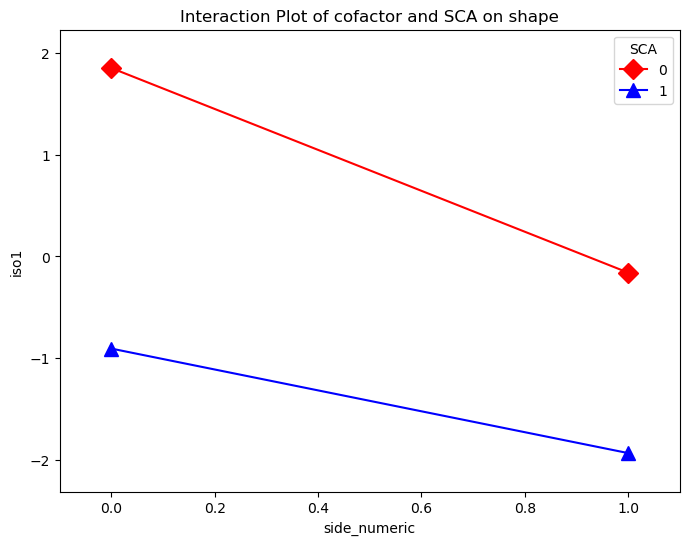

In [92]:
###########  Interaction plot for cofactors  ###########
from statsmodels.graphics.factorplots import interaction_plot

df = combined
df['side_numeric'] = pd.Categorical(df['side'].map({'L': 0, 'R': 1}), categories=[0, 1])
curData = 'iso1'
cofactor = 'side_numeric' #'Sex', 'Age', 'side_numeric'

# Interaction plot for cofactor
fig, ax = plt.subplots(figsize=(8, 6))
interaction_plot(df[cofactor], df['SCA'], df[curData], ax=ax, colors=['red', 'blue'], markers=['D', '^'], ms=10)
plt.title("Interaction Plot of cofactor and SCA on shape")
plt.xlabel(cofactor)
plt.ylabel(curData)
plt.show()